In [ ]:
import os
import numpy as np
import warnings
import tifffile
import cv2
from glob import glob

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
import matplotlib.animation as animation

PATH_OUTPUT = os.path.join('output', '201')
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [3]:
PATHS_PAZ = glob(os.path.join('..', 'data', 'paz','PAZ1_SAR_*.tif'))
PATHS_PAZ = sorted(PATHS_PAZ)

print(f'NUM OF PAZ: {len(PATHS_PAZ)}')

from osgeo import gdal

PATH_PAZ = PATHS_PAZ[0]

# Open tiff
ds = gdal.Open(PATH_PAZ)
ds.GetMetadata(), ds.GetProjection()

NUM OF PAZ: 14


Warning 1: ../data/paz/PAZ1_SAR_SSC_SL_D_SRA_20200318T165157_20200318T165159_TC.tif: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


({'AREA_OR_POINT': 'Area',
  'TIFFTAG_RESOLUTIONUNIT': '1 (unitless)',
  'TIFFTAG_XRESOLUTION': '1',
  'TIFFTAG_YRESOLUTION': '1'},
 'GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [4]:
import fiona
import rasterio
import rasterio.mask

In [5]:
PATH_ROOT = os.path.join('..', 'data', 'paz',)
PATH_CROP1 = os.path.join(PATH_ROOT, 'polygon', 'crop_001.geojson')

with fiona.open(PATH_CROP1, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

In [32]:
with rasterio.open(PATH_PAZ) as src:
    out_image, out_transform = rasterio.mask.mask(src, shapes, 
        crop=True, nodata=-1, filled=False)
    out_meta = src.meta
    print(out_meta)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 7821, 'height': 5233, 'count': 2, 'crs': CRS.from_epsg(4326), 'transform': Affine(2.432997503754215e-05, 0.0, 14.331486161204229,
       0.0, -2.432997503754215e-05, 50.27943214997817)}


In [38]:
out_meta.update({"driver": "GTiff",
                 "height": out_image.shape[1],
                 "width": out_image.shape[2],
                 "transform": out_transform,
})

PATH_OUTPUT_CROP = os.path.join(PATH_ROOT, 'crop_001_sample.tif')
with rasterio.open(PATH_OUTPUT_CROP, "w", **out_meta) as dest:
    dest.write(out_image)

(363, 622, 2) float32


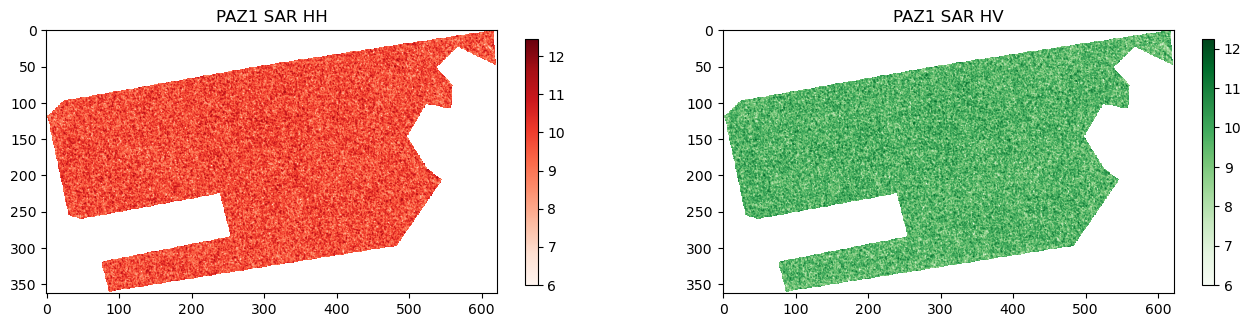

In [39]:
img = tifffile.imread(PATH_OUTPUT_CROP)
print(img.shape, img.dtype)

img_db = np.log(img + 1e-1)
POWER_MIN = 6

# plot
plt.figure(figsize=(16, 8), dpi=100, facecolor='w', edgecolor='k')
plt.subplot(1, 2, 1)
plt.imshow(img_db[:,:,0], cmap='Reds', vmin=POWER_MIN)
plt.title('PAZ1 SAR HH')
plt.colorbar(shrink=0.4)
# plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(img_db[:,:,1], cmap='Greens', vmin=POWER_MIN)
plt.colorbar(shrink=0.4)
plt.title('PAZ1 SAR HV')
# plt.axis('off')
plt.show();plt.clf();plt.close()


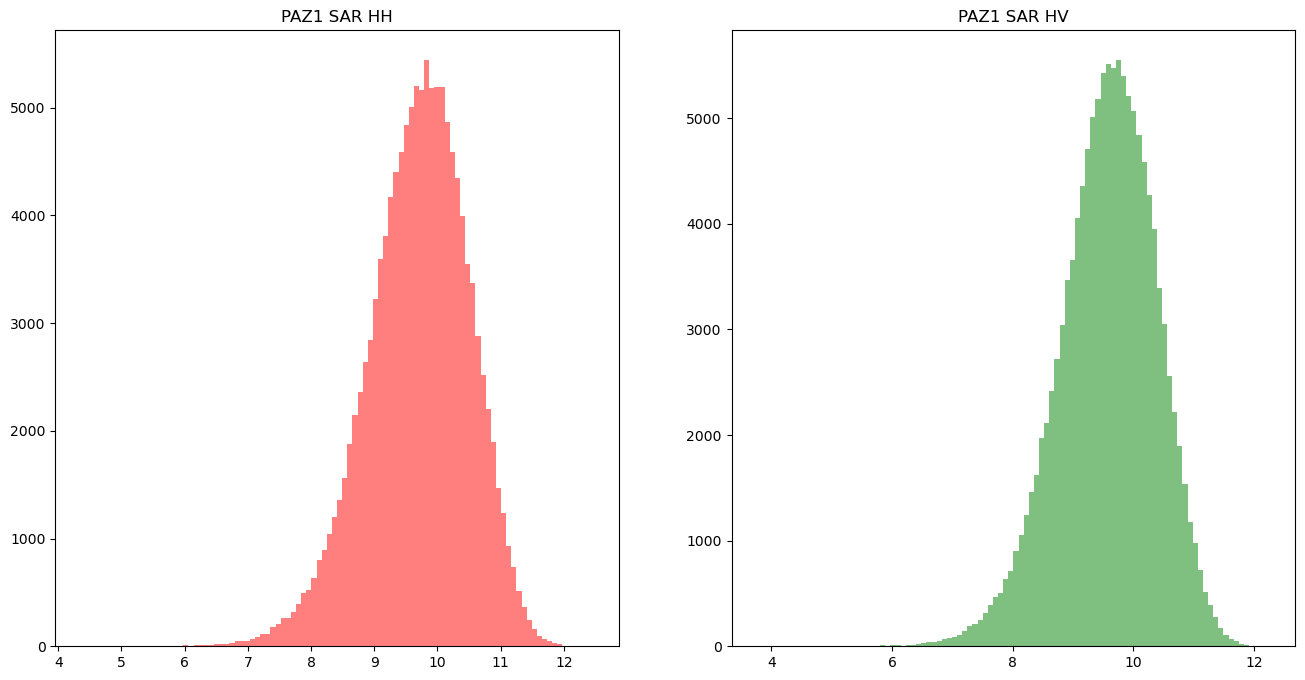

In [40]:
# histogram
plt.figure(figsize=(16, 8), dpi=100, facecolor='w', edgecolor='k')
plt.subplot(1, 2, 1)
plt.hist(img_db[:,:,0].flatten(), bins=100, color='r', alpha=0.5)
plt.title('PAZ1 SAR HH')
plt.subplot(1, 2, 2)
plt.hist(img_db[:,:,1].flatten(), bins=100, color='g', alpha=0.5)
plt.title('PAZ1 SAR HV')
plt.show();plt.clf();plt.close()


## Pipleline Processing

In [45]:
PATH_RASTER = os.path.join(PATH_ROOT, 'raster')
os.makedirs(PATH_RASTER, exist_ok=True)

area_of_interests = [
    f'crop_{str(iii+1).zfill(3)}'
    for iii in range(8)
] + ['airport', 'tree']

PATHS_GEOJSON = [
    os.path.join(PATH_ROOT, 'polygon', f'{area}.geojson')
    for area in area_of_interests
]

# area crop process
for idx_tif, PATH_PAZ in tqdm(enumerate(PATHS_PAZ), total=len(PATHS_PAZ)):
    # print(f'PROCESSING: {idx_tif+1}/{len(PATHS_PAZ)}')
    file_name_tif = os.path.basename(PATH_PAZ).split('.')[0]
    
    for idx_geojson, PATH_AREA_GEOJSON in enumerate(PATHS_GEOJSON):
        # polygon 
        with fiona.open(PATH_AREA_GEOJSON, "r") as shapefile:
            shapes = [feature["geometry"] for feature in shapefile]
        file_name_geojson = os.path.basename(PATH_AREA_GEOJSON).split('.')[0]
        
        # crop 
        with rasterio.open(PATH_PAZ) as src:
            out_image, out_transform = rasterio.mask.mask(src, shapes, 
                crop=True, nodata=-1, filled=True)
            out_meta = src.meta

        # write output
        out_meta.update({"driver": "GTiff",
                        "height": out_image.shape[1],
                        "width": out_image.shape[2],
                        "transform": out_transform,})
        PATH_OUTPUT_CROP = os.path.join(PATH_RASTER, 
                                        f'{file_name_tif}_{file_name_geojson}.tif')
        with rasterio.open(PATH_OUTPUT_CROP, "w", **out_meta) as dest:
            dest.write(out_image)

100%|██████████| 14/14 [00:05<00:00,  2.47it/s]
